## Task 7: Root System Architecture (RSA) Extraction

In this task, we transition from simple root segmentation to a more structured understanding of root morphology. While a root mask distinguishes root pixels (value `1`) from non-root pixels (value `0`), it lacks information about how different root segments are connected or organized.

Root System Architecture (RSA) extraction addresses this gap by analyzing the structure of the root network. This process involves identifying individual root branches, classifying them by type (e.g., primary, secondary), and detecting their start and end points. 

This structural understanding enables more advanced biological and robotic analyses. In particular, for robotic tasks such as inoculating plants at their root tips, it is crucial to identify the coordinates of primary root tips.

This task does not have deliverables, as it serves as a preprocessing step for subsequent tasks. Root tip coordinates are extracted during this stage, but will be utilized in later analyses.

In [1]:
# Imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skan.csr import skeleton_to_csgraph
import numpy as np

### Step 1: Load and threshold the root mask

We begin by loading the grayscale root mask for a given plant. This image uses pixel values from 0 to 255, where root regions are represented by non-zero intensities.

To simplify further processing, we **binarize** the mask by converting all non-zero pixels to `1` (root) and keeping zero values as `0` (background). This binary mask clearly separates root structures from the background and serves as the foundation for identifying the root system architecture.

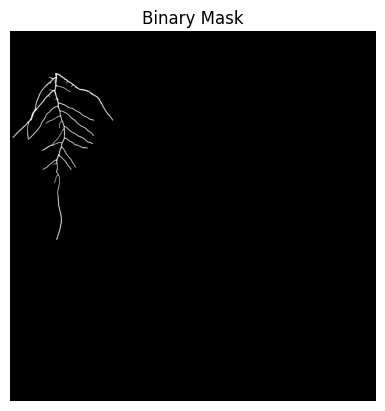

In [2]:
# Load the grayscale root mask (values from 0 to 255)
mask_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25b-fai2-adsai-ViktoriaKubisova231781\datalab_tasks\task6\10_masks\plant_1.png"
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

# Binarize the mask
binary = (mask > 0).astype(np.uint8)

# Visualize the binary mask
plt.imshow(binary, cmap='gray')
plt.title("Binary Mask")
plt.axis('off')
plt.show()

### Step 2: Identify the main root component

With the binary root mask prepared, the next step is to identify individual connected components within the image. These components represent distinct, contiguous root regions.

Using OpenCV’s `connectedComponentsWithStats`, we label all connected regions and extract statistics such as area. We then isolate the **largest non-background component**, assuming this represents the main root structure.

This step ensures that further analysis focuses only on the primary root system, filtering out small artifacts or noise. The resulting mask highlights only the largest connected root region.

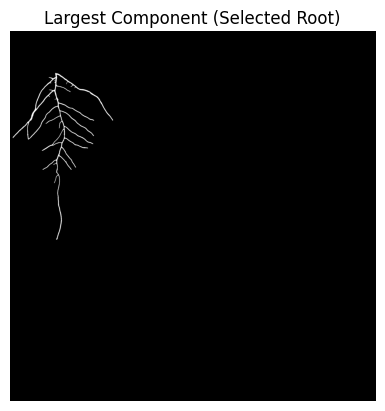

In [3]:
# Identify connected components
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)

# Find the largest non-background component (skip label 0)
largest_component = np.argmax(stats[1:, cv2.CC_STAT_AREA]) + 1

# Create a mask for the largest component
component_mask = (labels == largest_component).astype(np.uint8)

# Visualize the selected root component
plt.imshow(component_mask, cmap='gray')
plt.title("Largest Component (Selected Root)")
plt.axis('off')
plt.show()

### Step 4: Skeletonize the root

To extract the structure of the root system, we perform **skeletonization** on the binary root mask. Skeletonization reduces thick root structures to a one-pixel-wide representation, preserving the overall topology while simplifying the geometry.

This skeleton forms the basis for extracting root paths, measuring lengths, and identifying key points like branch intersections and root tips.

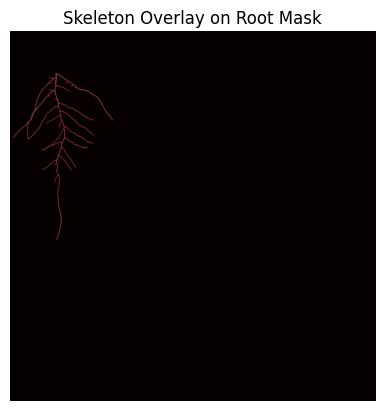

In [4]:
# Skeletonize the root mask
from skimage.morphology import skeletonize
skeleton = skeletonize(component_mask)

# Show the skeleton
plt.imshow(component_mask, cmap='gray')
plt.imshow(skeleton, cmap='hot', alpha=0.8)  # bright overlay
plt.title("Skeleton Overlay on Root Mask")
plt.axis('off')
plt.show()

### Step 5: Crop to root bounding box

To simplify further analysis and reduce computational load, we crop the skeleton to the **bounding box** of the largest root component. This step focuses the processing on the relevant region of interest, eliminating empty space around the root.

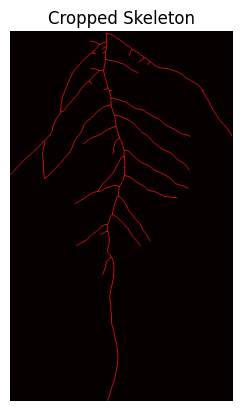

In [5]:
# Get bounding box of the root
x, y, w, h, _ = stats[largest_component]

# Crop skeleton to bounding box
cropped_skel = skeleton[y:y+h, x:x+w]

# Show cropped skeleton
plt.imshow(cropped_skel, cmap='gray')
plt.imshow(cropped_skel, cmap='hot', alpha=0.8) 
plt.title("Cropped Skeleton")
plt.axis('off')
plt.show()

### Step 6: Graph construction from skeleton

With the root skeleton extracted and cropped, we now convert it into a **graph representation**. In this graph:

- **Nodes** represent junctions, endpoints, or intersections in the skeleton.
- **Edges** represent root segments between these nodes, weighted by their physical length.

We use the `skan` library to process the skeleton and extract its topology. Then, we build a weighted graph using `NetworkX`, where each edge is weighted by the actual pixel distance of the corresponding root branch.

This graph-based representation is essential for measuring root lengths and tracing primary paths. 

C:\Users\vikku\AppData\Local\Temp\ipykernel_31648\3208111047.py:12: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  branch_data = summarize(skeleton_obj)


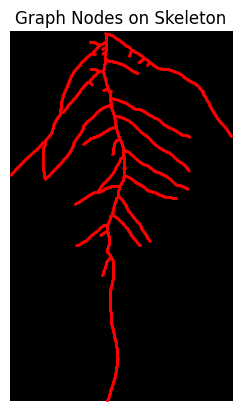

In [6]:
# Import skeleton and graph tools
from skan import Skeleton, summarize
from skan.csr import skeleton_to_csgraph
import networkx as nx

# Build graph from skeleton
g0, c0 = skeleton_to_csgraph(cropped_skel)
node_coordinates = np.transpose(c0)

# Summarize skeleton structure
skeleton_obj = Skeleton(cropped_skel)
branch_data = summarize(skeleton_obj)

# Create graph with edge weights
G = nx.from_pandas_edgelist(branch_data, source='node-id-src', target='node-id-dst', edge_attr='branch-distance')

# Show graph nodes over skeleton
plt.imshow(cropped_skel, cmap='gray')
plt.scatter(node_coordinates[:, 1], node_coordinates[:, 0], s=1, c='red', alpha=0.5)
plt.title("Graph Nodes on Skeleton")
plt.axis('off')
plt.show()

### Step 7: Find tips and trace the primary root path

To estimate the **primary root length**, we analyze the graph to identify tip nodes — nodes with only one connection (degree = 1). These typically correspond to **root tips or endpoints**.

By comparing their vertical (Y-axis) positions:
- The **lowest node** is assumed to be the bottom-most root tip.
- The **highest node** is assumed to be the shoot-root junction (top of the root system).

We then compute the **shortest path** between these two nodes using edge weights based on physical (pixel) distance. This path is interpreted as the primary root, and its total length is calculated accordingly.

If no valid path is found, the length is set to zero.


In [7]:
# Get tip nodes (degree = 1)
tip_nodes = [node for node, degree in G.degree() if degree == 1]

# Get coordinates of tip nodes
tip_coords = {node: node_coordinates[node] for node in tip_nodes}

# Find lowest and highest tips by Y value
lowest_node = max(tip_coords, key=lambda node: tip_coords[node][0])
highest_node = min(tip_coords, key=lambda node: tip_coords[node][0])

# Find shortest path between them
try:
    shortest_path = nx.shortest_path(G, source=lowest_node, target=highest_node, weight='branch-distance')
    path_edges = list(zip(shortest_path, shortest_path[1:]))
    total_distance = nx.shortest_path_length(G, source=lowest_node, target=highest_node, weight='branch-distance')
except nx.NetworkXNoPath:
    print("No path found.")
    shortest_path = []
    total_distance = 0

### Step 8: Final visualization — primary root path

To wrap up the analysis, we generate a final visualization overlaying the **root skeleton graph**, **tip nodes**, and the **traced primary root path**.

Using `skan`'s drawing utilities along with `matplotlib`, we:
- Display the full root skeleton as a graph
- Highlight the **start tip** (lowest node) in pink and the **end tip** (highest node) in blue
- Draw the **primary root path** in red to clearly show the traced route


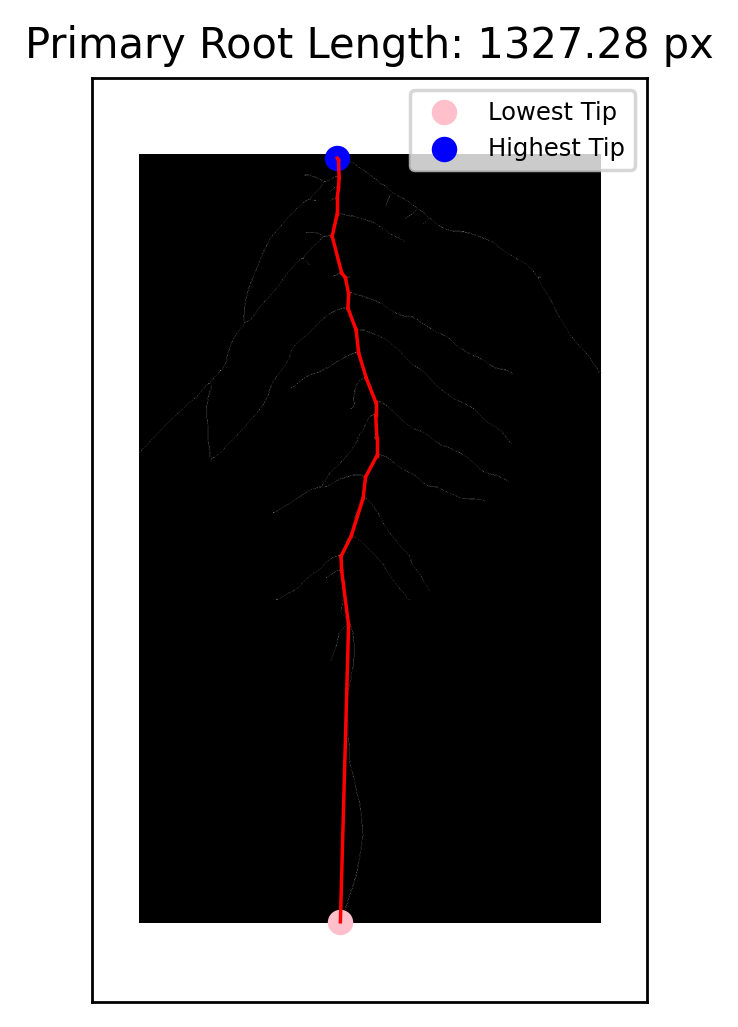

In [8]:
# Import skan's drawing tool
from skan import draw

# Create plot with skeleton and graph
fig, ax = plt.subplots()
draw.overlay_skeleton_networkx(g0, node_coordinates, image=cropped_skel, axis=ax, node_size=0, with_labels=False)

if shortest_path:
    # Mark lowest and highest tip nodes
    ax.scatter(*tip_coords[lowest_node][::-1], color='pink', s=40, label='Lowest Tip')
    ax.scatter(*tip_coords[highest_node][::-1], color='blue', s=40, label='Highest Tip')

    # Draw the primary root path in red
    for u, v in path_edges:
        p1, p2 = node_coordinates[u], node_coordinates[v]
        ax.plot([p1[1], p2[1]], [p1[0], p2[0]], color='red', lw=1.0)

    ax.set_title(f"Primary Root Length: {total_distance:.2f} px")
    # Set legend to top-right corner with smaller font
    ax.legend(loc='upper right', fontsize=7 , frameon=True)
else:
    # If no path found, show fallback title
    ax.set_title("No valid path found.")

# Set DPI and show plot
fig.set_dpi(250)
plt.show()

### Step 10: Output measurements

After tracing the primary root path, we print out the key measurements:

- **Primary root length** (in pixels)
- Coordinates of the **start tip** (typically the bottom-most root tip)
- Coordinates of the **end tip** (typically the top/root base)

In [9]:
#  Step 10: Output Measurements
print(f"Primary root length: {total_distance:.2f} pixels")
print(f"Start tip: {tip_coords[lowest_node]}")
print(f"End tip: {tip_coords[highest_node]}")

Primary root length: 1327.28 pixels
Start tip: [1217  319]
End tip: [  5 314]


### Full pipeline: Batch RSA extraction and visualization

This cell implements a **complete end-to-end pipeline** that automates the Root System Architecture (RSA) extraction process for **all root mask images** in the dataset.

The script performs the following key steps for each `.png` file in the input folder:

1. **Load and binarize root mask**  
   Reads each grayscale root mask and thresholds it to create a binary image distinguishing root pixels from the background.

2. **Extract the main root component**  
   Uses connected component analysis to isolate the largest contiguous root region, filtering out noise or detached fragments.

3. **Skeletonization**  
   Converts the binary root region into a one-pixel-wide skeleton that preserves root topology.

4. **Crop to root bounding box**  
   Reduces the image area to focus only on the relevant root region, improving processing efficiency.

5. **Graph construction**  
   Transforms the skeleton into a graph, where nodes represent junctions or endpoints and edges represent root segments weighted by physical distance.

6. **Primary root path identification**  
   Detects root tips (graph nodes with degree = 1), identifies the top and bottom tips based on Y-coordinate, and calculates the shortest path between them — interpreted as the **primary root**.

7. **Visualization and output**  
   Overlays the primary root path on the skeleton, highlights the tip nodes, displays the image, and saves the result to an output directory. The primary root length is printed for each processed file.


C:\Users\vikku\AppData\Local\Temp\ipykernel_31648\1629406761.py:41: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  branch_data = summarize(skeleton_obj)


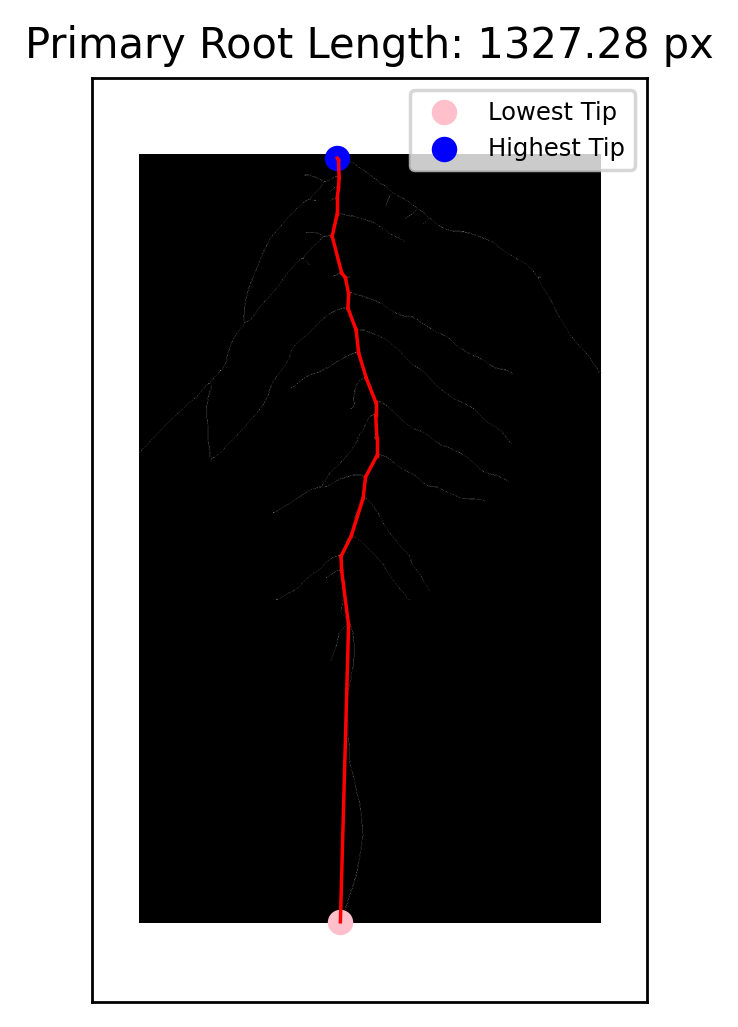

Processed plant_1.png — Root Length: 1327.28 px


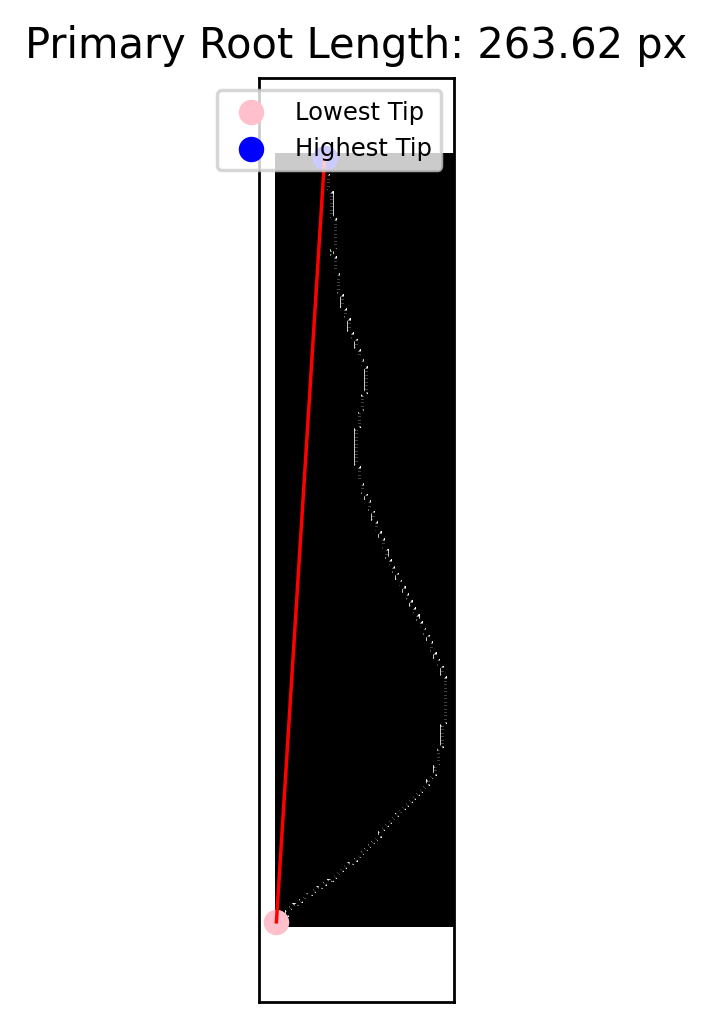

Processed plant_2.png — Root Length: 263.62 px


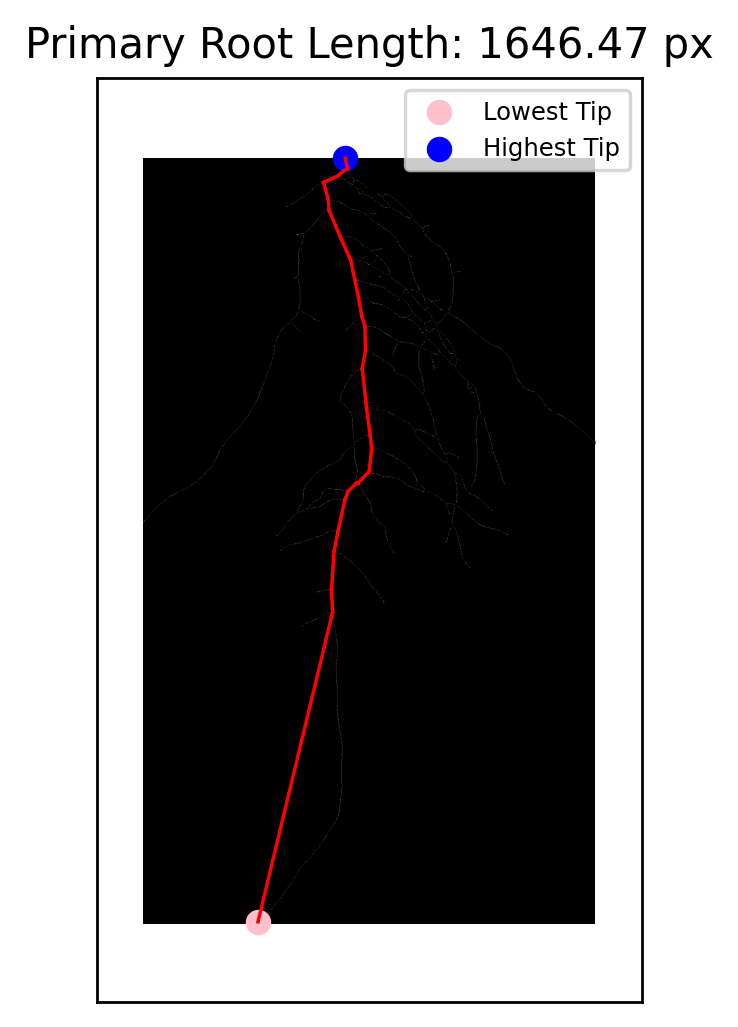

Processed plant_3.png — Root Length: 1646.47 px
Failed to process plant_4.png: attempt to get argmax of an empty sequence


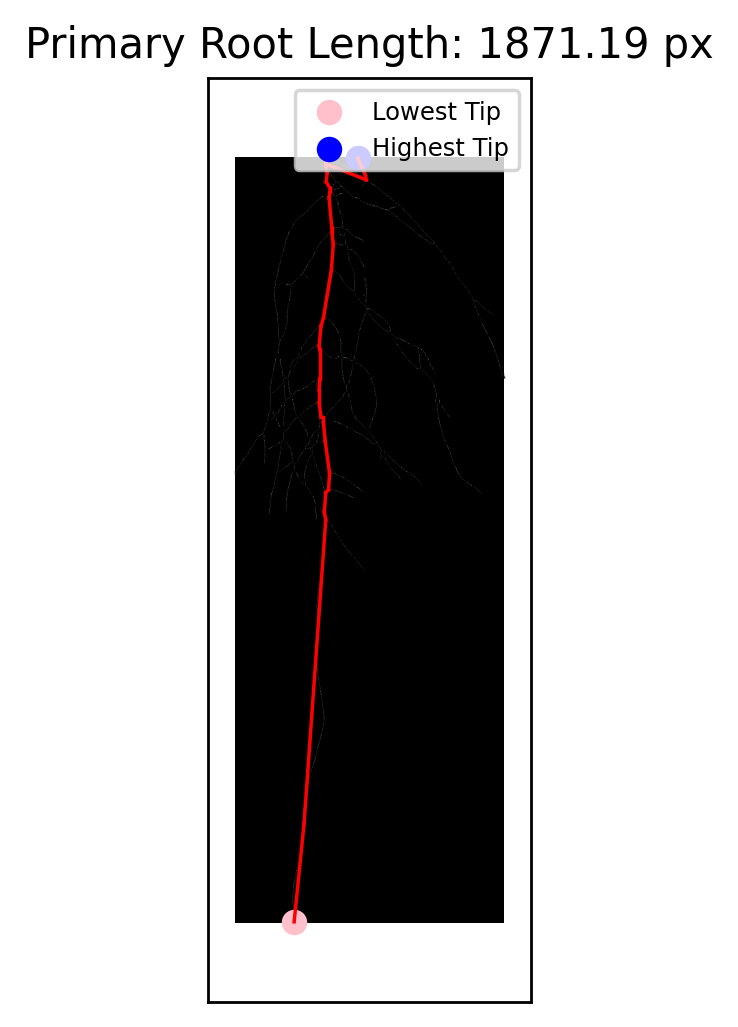

Processed plant_5.png — Root Length: 1871.19 px


In [10]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skan import Skeleton, summarize, draw
from skan.csr import skeleton_to_csgraph
import networkx as nx

# Input/output directories
input_dir = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25b-fai2-adsai-ViktoriaKubisova231781\datalab_tasks\task6\10_masks"
output_dir = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25b-fai2-adsai-ViktoriaKubisova231781\datalab_tasks\task7\10_roots"

os.makedirs(output_dir, exist_ok=True)

# Loop through all PNG mask images
for filename in os.listdir(input_dir):
    if filename.lower().endswith('.png'):
        try:
            # Load and binarize mask
            mask_path = os.path.join(input_dir, filename)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            binary = (mask > 0).astype(np.uint8)

            # Connected components
            num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
            largest_component = np.argmax(stats[1:, cv2.CC_STAT_AREA]) + 1
            component_mask = (labels == largest_component).astype(np.uint8)

            # Skeletonize
            skeleton = skeletonize(component_mask)

            # Crop to bounding box
            x, y, w, h, _ = stats[largest_component]
            cropped_skel = skeleton[y:y+h, x:x+w]

            # Graph construction
            g0, c0 = skeleton_to_csgraph(cropped_skel)
            node_coordinates = np.transpose(c0)
            skeleton_obj = Skeleton(cropped_skel)
            branch_data = summarize(skeleton_obj)
            G = nx.from_pandas_edgelist(branch_data, source='node-id-src', target='node-id-dst', edge_attr='branch-distance')

            # Identify tip nodes
            tip_nodes = [node for node, degree in G.degree() if degree == 1]
            tip_coords = {node: node_coordinates[node] for node in tip_nodes}
            lowest_node = max(tip_coords, key=lambda node: tip_coords[node][0])
            highest_node = min(tip_coords, key=lambda node: tip_coords[node][0])

            # Trace shortest path
            try:
                shortest_path = nx.shortest_path(G, source=lowest_node, target=highest_node, weight='branch-distance')
                path_edges = list(zip(shortest_path, shortest_path[1:]))
                total_distance = nx.shortest_path_length(G, source=lowest_node, target=highest_node, weight='branch-distance')
            except nx.NetworkXNoPath:
                shortest_path = []
                total_distance = 0

            # Final visualization
            fig, ax = plt.subplots()
            draw.overlay_skeleton_networkx(g0, node_coordinates, image=cropped_skel, axis=ax, node_size=0, with_labels=False)

            if shortest_path:
                ax.scatter(*tip_coords[lowest_node][::-1], color='pink', s=40, label='Lowest Tip')
                ax.scatter(*tip_coords[highest_node][::-1], color='blue', s=40, label='Highest Tip')

                for u, v in path_edges:
                    p1, p2 = node_coordinates[u], node_coordinates[v]
                    ax.plot([p1[1], p2[1]], [p1[0], p2[0]], color='red', lw=1.0)

                ax.set_title(f"Primary Root Length: {total_distance:.2f} px")
                ax.legend(loc='upper right', fontsize=7, frameon=True)
            else:
                ax.set_title("No valid path found.")

            fig.set_dpi(250)

            # Display the image
            plt.show()

            # Save output figure
            out_path = os.path.join(output_dir, f"{os.path.splitext(filename)[0]}_root.png")
            fig.savefig(out_path, bbox_inches='tight')
            plt.close(fig)

            print(f"Processed {filename} — Root Length: {total_distance:.2f} px")

        except Exception as e:
            print(f"Failed to process {filename}: {e}")


### Alternative RSA approach: Longest & most vertical root path

In this approach, we experiment with a **heuristic method** to identify the **primary root** by selecting the **longest, most vertical, and centrally located path** in the root skeleton.

Rather than assuming the primary root runs from the highest to the lowest tip (as in the original method), we apply a scoring strategy that evaluates all tip-to-tip paths based on a combination of:

- **Length**: Longer paths are preferred.
- **Verticality**: Paths with greater displacement along the Y-axis are favored.
- **Centrality**: Paths closer to the horizontal center of the image are preferred.

This strategy may be more robust for complex or asymmetrical root systems where the primary root isn't perfectly vertical or doesn't stretch from edge to edge.

---

###  Key steps in this method:

1. **Load & preprocess**  
   Load a root mask, binarize it, extract the largest component, and skeletonize it.

2. **Build skeleton graph**  
   Create a graph representation of the skeleton using `skan` and `networkx`.

3. **Find tip nodes**  
   Tip nodes (degree = 1) are assumed to be potential root tips.

4. **Trace sll tip-to-tip paths**  
   Use Dijkstra’s algorithm to find all shortest paths from each tip to every other node.

5. **Score paths based on heuristics**  
   For each path, calculate a custom score that rewards vertical alignment and central location.

6. **Select the best path as primary root**  
   The path with the highest score is selected as the **primary root path**.

7. **Branch classification**  
   All edges along the best path are classified as **primary root branches**; the rest are labeled as **lateral roots**.

8. **Color-coded visualization**  
   The final visualization shows the root system architecture, with **primary roots in red** and **lateral roots in orange**.

---

### Benefits of this approach

- **More flexible**: Doesn't rely strictly on top-bottom assumptions.
- **Heuristic-driven**: Adapts to variations in root orientation and shape.
- **More informative**: Differentiates between primary and lateral branches, useful for structural analysis.



C:\Users\vikku\AppData\Local\Temp\ipykernel_31648\1405066869.py:28: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  branch_data = summarize(skeleton_obj)


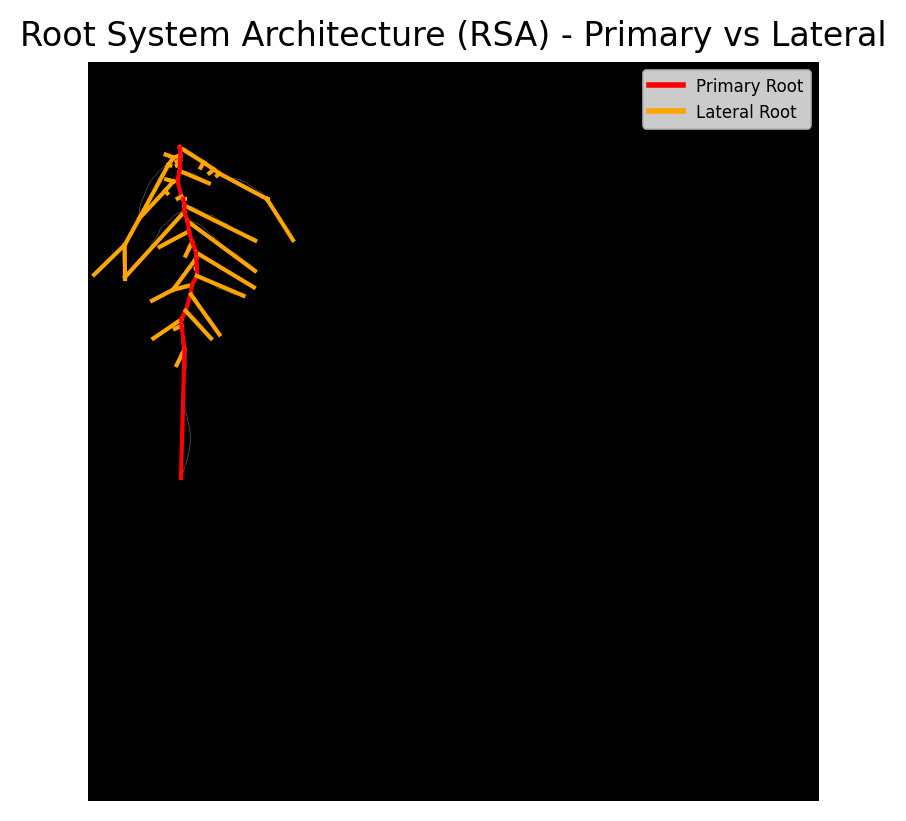

Primary root length: 1327.28 pixels
Primary root path: [4786, 4253, 3998, 3891, 3785, 3582, 3363, 3130, 2925, 2643, 2476, 2214, 1855, 1583, 1322, 1168, 1056, 1008, 697, 396, 261, 188, 107, 3, 0]


In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skan import Skeleton, summarize, draw
from skan.csr import skeleton_to_csgraph
import networkx as nx

# Load root mask
mask_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25b-fai2-adsai-ViktoriaKubisova231781\datalab_tasks\task6\10_masks\plant_1.png"
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
binary_mask = (mask > 0).astype(np.uint8)

# Find connected components (root parts)
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)

# Select the largest component (root)
largest_component = np.argmax(stats[1:, cv2.CC_STAT_AREA]) + 1
component_mask = (labels == largest_component).astype(np.uint8)

# Skeletonize the mask
skeleton = skeletonize(component_mask)

# Create graph from skeleton
g0, c0 = skeleton_to_csgraph(skeleton)
node_coordinates = np.transpose(c0)
skeleton_obj = Skeleton(skeleton)
branch_data = summarize(skeleton_obj)

# Build graph from branch data
G = nx.from_pandas_edgelist(branch_data, source='node-id-src', target='node-id-dst', edge_attr='branch-distance')

# Identify all tip nodes (degree = 1)
tip_nodes = [node for node, degree in G.degree() if degree == 1]

# Find the longest path using Dijkstra's algorithm from each tip node
longest_path = []
best_score = 0

height, width = skeleton.shape
image_center_x = width / 2

for tip in tip_nodes:
    lengths, paths = nx.single_source_dijkstra(G, tip, weight='branch-distance')
    for target, length in lengths.items():
        path = paths[target]
        if len(path) < 2:
            continue

        # Get vertical displacement (Y axis)
        y_start = node_coordinates[path[0]][0]
        y_end = node_coordinates[path[-1]][0]
        delta_y = abs(y_end - y_start)

        # Get horizontal midline distance
        x_coords = [node_coordinates[n][1] for n in path]
        avg_x = np.mean(x_coords)
        x_dist_from_center = abs(avg_x - image_center_x)

        # Compute verticality score
        vertical_ratio = delta_y / (length + 1e-6)  # avoid divide-by-zero
        center_penalty = x_dist_from_center / width  # normalized

        # Final score: favor long + vertical + centered paths
        score = vertical_ratio * length * (1 - center_penalty)

        if score > best_score:
            best_score = score
            longest_path = path
            best_length = length


# Classify the root branches based on the longest path
# Label branches as primary (1) or lateral (2)
primary_root_edges = set(zip(longest_path[:-1], longest_path[1:]))
branch_data['branch-type'] = branch_data.apply(
    lambda row: 1 if (row['node-id-src'], row['node-id-dst']) in primary_root_edges or
                     (row['node-id-dst'], row['node-id-src']) in primary_root_edges else 2,
    axis=1
)

# Visualize the RSA with color-coded branches
branch_colors = {1: 'red', 2: 'orange'}  # Red for primary, orange for lateral

fig, ax = plt.subplots()
ax.imshow(skeleton, cmap='gray')

# Draw each branch with its corresponding color
for _, row in branch_data.iterrows():
    src = int(row['node-id-src'])
    dst = int(row['node-id-dst'])
    color = branch_colors[row['branch-type']]
    
    # Get coordinates of source and destination nodes
    p1 = node_coordinates[src]
    p2 = node_coordinates[dst]
    
    # Plot line segment
    ax.plot([p1[1], p2[1]], [p1[0], p2[0]], color=color, lw=1.5)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', lw=2, label='Primary Root'),
    Line2D([0], [0], color='orange', lw=2, label='Lateral Root')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=6, frameon=True)

ax.set_title("Root System Architecture (RSA) - Primary vs Lateral")
ax.axis('off')
fig.set_dpi(200)
plt.show()

# Print Results
print(f"Primary root length: {best_length:.2f} pixels")
print(f"Primary root path: {longest_path}")

### Fill pipeline: Alternative RSA approach

C:\Users\vikku\AppData\Local\Temp\ipykernel_31648\45167884.py:45: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  branch_data = summarize(skeleton_obj)


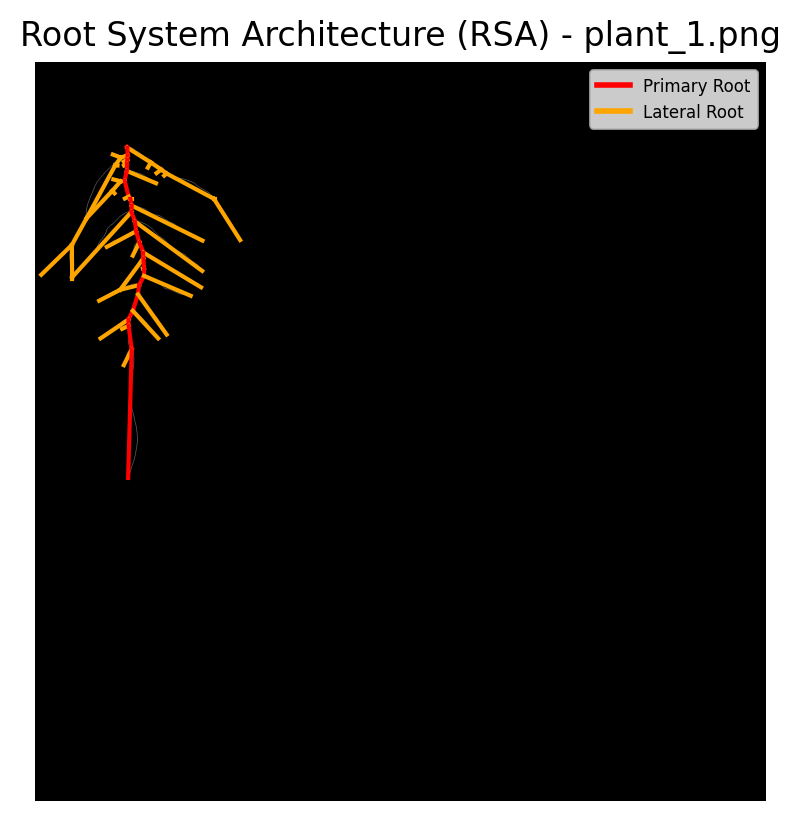

plant_1.png: Primary root length = 1327.28 pixels
Primary root path: [4786, 4253, 3998, 3891, 3785, 3582, 3363, 3130, 2925, 2643, 2476, 2214, 1855, 1583, 1322, 1168, 1056, 1008, 697, 396, 261, 188, 107, 3, 0]


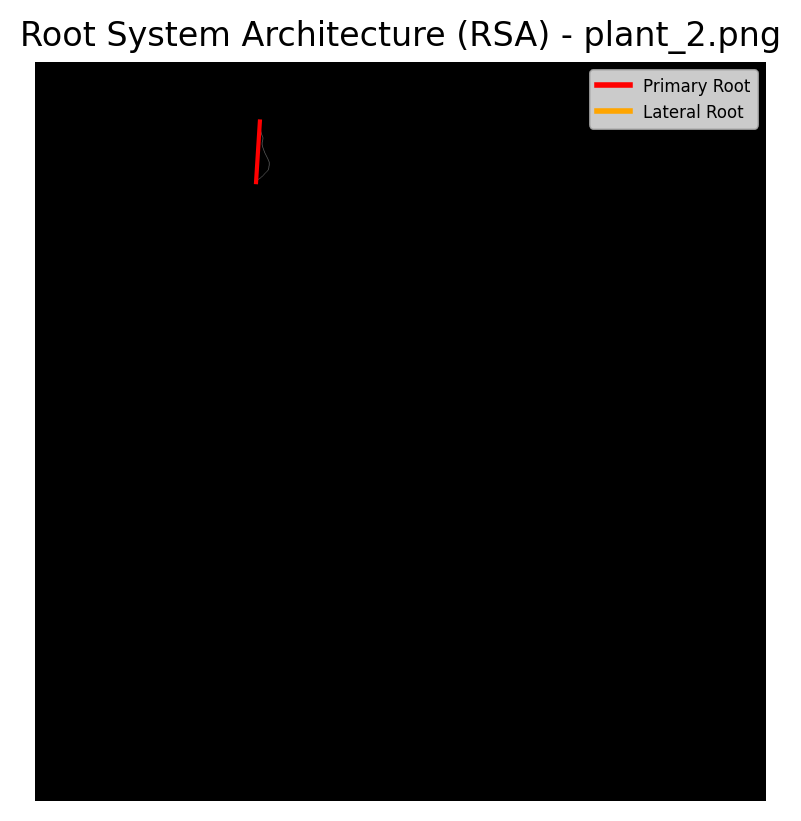

plant_2.png: Primary root length = 263.62 pixels
Primary root path: [0, 227]


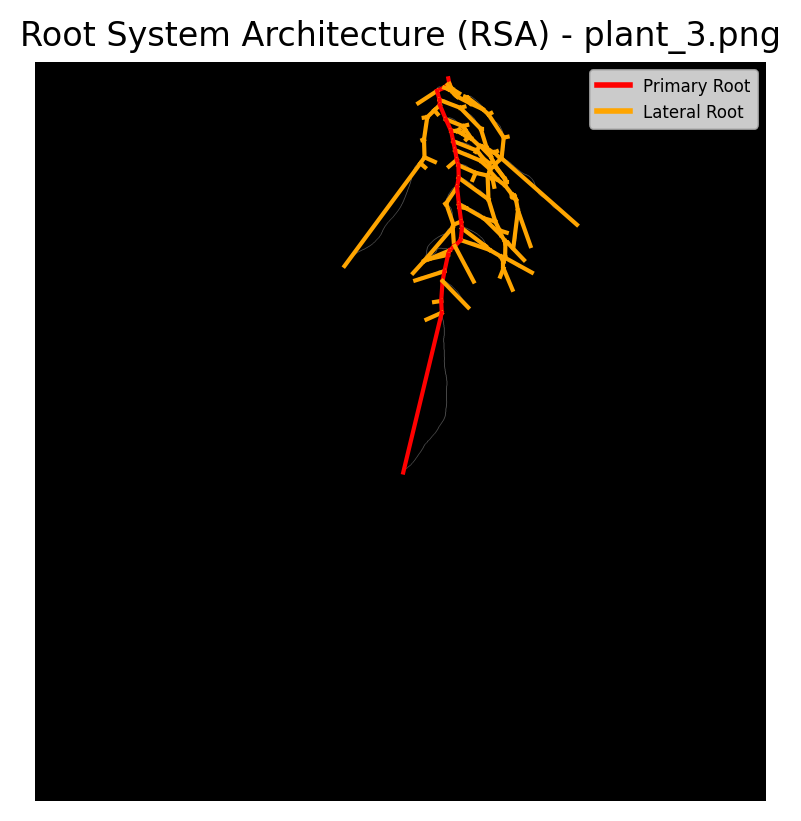

plant_3.png: Primary root length = 1646.47 pixels
Primary root path: [0, 21, 36, 76, 158, 366, 531, 881, 1158, 1464, 1758, 2136, 2373, 2876, 3217, 3720, 3805, 4333, 4560, 5017, 5298, 5295, 5526, 5716, 6268, 6504, 6710, 6797, 7439]
Failed to process plant_4.png: attempt to get argmax of an empty sequence


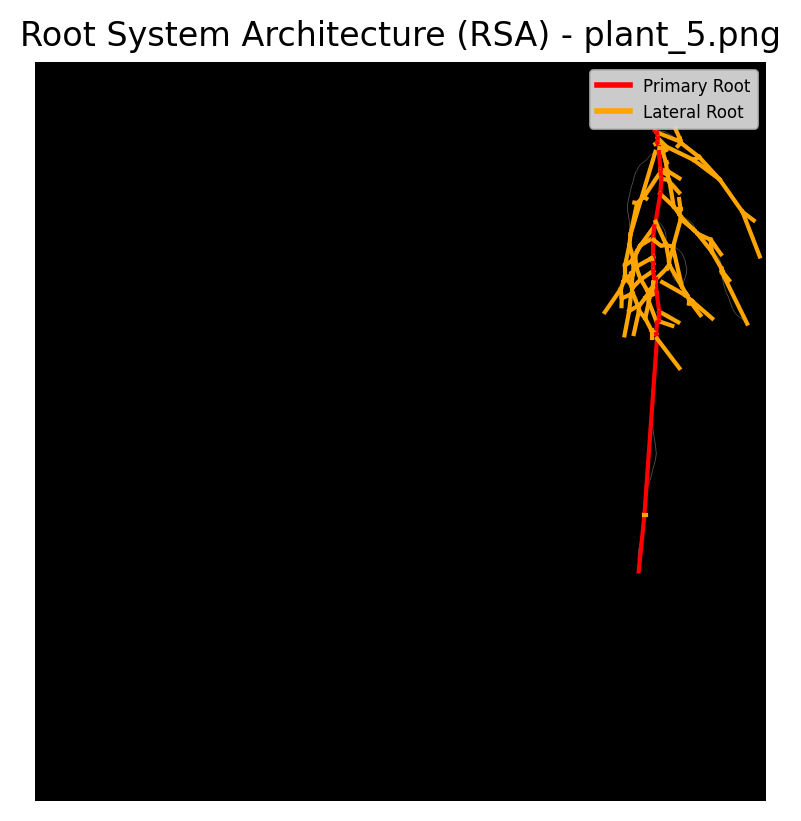

plant_5.png: Primary root length = 1725.41 pixels
Primary root path: [6, 45, 120, 208, 295, 330, 412, 836, 919, 1123, 1480, 2217, 2362, 2747, 2825, 3592, 3839, 4118, 4481, 4497, 4616, 5094, 5906, 6261, 6325, 6541, 6580, 7337, 7549]


In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skan import Skeleton, summarize, draw
from skan.csr import skeleton_to_csgraph
import networkx as nx
from matplotlib.lines import Line2D

# Input and output directories
input_dir = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25b-fai2-adsai-ViktoriaKubisova231781\datalab_tasks\task6\10_masks"
output_dir = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25b-fai2-adsai-ViktoriaKubisova231781\datalab_tasks\task7\10_roots"
os.makedirs(output_dir, exist_ok=True)

# Loop through all PNG mask images
for filename in os.listdir(input_dir):
    if not filename.lower().endswith('.png'):
        continue

    mask_path = os.path.join(input_dir, filename)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        print(f"Skipping file (not readable): {filename}")
        continue

    try:
        # Load root mask
        binary_mask = (mask > 0).astype(np.uint8)

        # Find connected components (root parts)
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)

        # Select the largest component (root)
        largest_component = np.argmax(stats[1:, cv2.CC_STAT_AREA]) + 1
        component_mask = (labels == largest_component).astype(np.uint8)

        # Skeletonize the mask
        skeleton = skeletonize(component_mask)

        # Create graph from skeleton
        g0, c0 = skeleton_to_csgraph(skeleton)
        node_coordinates = np.transpose(c0)
        skeleton_obj = Skeleton(skeleton)
        branch_data = summarize(skeleton_obj)

        # Build graph from branch data
        G = nx.from_pandas_edgelist(branch_data, source='node-id-src', target='node-id-dst', edge_attr='branch-distance')

        # Identify all tip nodes (degree = 1)
        tip_nodes = [node for node, degree in G.degree() if degree == 1]

        # Find the longest path using Dijkstra's algorithm from each tip node
        longest_path = []
        best_score = 0
        best_length = 0

        height, width = skeleton.shape
        image_center_x = width / 2

        for tip in tip_nodes:
            lengths, paths = nx.single_source_dijkstra(G, tip, weight='branch-distance')
            for target, length in lengths.items():
                path = paths[target]
                if len(path) < 2:
                    continue

                # Get vertical displacement (Y axis)
                y_start = node_coordinates[path[0]][0]
                y_end = node_coordinates[path[-1]][0]
                delta_y = abs(y_end - y_start)

                # Get horizontal midline distance
                x_coords = [node_coordinates[n][1] for n in path]
                avg_x = np.mean(x_coords)
                x_dist_from_center = abs(avg_x - image_center_x)

                # Compute verticality score
                vertical_ratio = delta_y / (length + 1e-6)  # avoid divide-by-zero
                center_penalty = x_dist_from_center / width  # normalized

                # Final score: favor long + vertical + centered paths
                score = vertical_ratio * length * (1 - center_penalty)

                if score > best_score:
                    best_score = score
                    longest_path = path
                    best_length = length

        # Classify the root branches based on the longest path
        # Label branches as primary (1) or lateral (2)
        primary_root_edges = set(zip(longest_path[:-1], longest_path[1:]))
        branch_data['branch-type'] = branch_data.apply(
            lambda row: 1 if (row['node-id-src'], row['node-id-dst']) in primary_root_edges or
                             (row['node-id-dst'], row['node-id-src']) in primary_root_edges else 2,
            axis=1
        )

        # Visualize the RSA with color-coded branches
        branch_colors = {1: 'red', 2: 'orange'}  # Red for primary, orange for lateral

        fig, ax = plt.subplots()
        ax.imshow(skeleton, cmap='gray')

        # Draw each branch with its corresponding color
        for _, row in branch_data.iterrows():
            src = int(row['node-id-src'])
            dst = int(row['node-id-dst'])
            color = branch_colors[row['branch-type']]
            p1 = node_coordinates[src]
            p2 = node_coordinates[dst]
            ax.plot([p1[1], p2[1]], [p1[0], p2[0]], color=color, lw=1.5)

        # Add legend
        legend_elements = [
            Line2D([0], [0], color='red', lw=2, label='Primary Root'),
            Line2D([0], [0], color='orange', lw=2, label='Lateral Root')
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=6, frameon=True)

        ax.set_title(f"Root System Architecture (RSA) - {filename}")
        ax.axis('off')
        fig.set_dpi(200)

        # Show plot
        plt.show()

        # Save visualization
        output_path = os.path.join(output_dir, f"{os.path.splitext(filename)[0]}_rsa.png")
        fig.savefig(output_path, bbox_inches='tight')
        plt.close(fig)

        # Print Results
        print(f"{filename}: Primary root length = {best_length:.2f} pixels")
        print(f"Primary root path: {longest_path}")

    except Exception as e:
        print(f"Failed to process {filename}: {e}")